# Plot best performing models from control runs

In [1]:
# input files
pmodelsfiles = '../control_run/best_perf_proto.dict'
truthfile = '../control_run/truth.dict'
nmodels = 10

In [2]:
import sys,os,copy,glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
plt.rcParams["text.usetex"] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Palatino'
plt.rcParams['font.weight'] = '700'
plt.rcParams['axes.labelweight'] = '700'

plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "figure.dpi": 300,
    "axes.linewidth": 1.4,
})

In [4]:
pBest = None

In [5]:
#Get highest score from each run:

protomodelsDict = []
#for ff in glob.glob(pmodelsfiles):
with open(pmodelsfiles,'r') as f:
    pList = eval(f.read())
    print(len(pList))
    for p in pList:
        if p['step'] < 1000: continue  #wait for 1000 steps as burn-in 
        walk = p['walkerid']
        #print ( f"pDict {list(pList)[0]}" )
        #pList = [fromDict(pDict) for pDict in pList[:]]
        #p = sorted(pList, key = lambda p: p["K"], reverse=True)[0]
        protomodelsDict.append(p)
        if pBest is None or pBest["K"] < p["K"]:
            pBest = p


protomodelsDict = sorted(protomodelsDict, key = lambda p: p['K'], reverse=True)[:10]

20


In [6]:
#Get informartion of the injected protomodel signal
pTrue = None
with open ( truthfile, "rt" ) as f:
    pTrue = eval(f.read())

print(pTrue['K'], pTrue['TL'])

13.327459710768903 17.152459710768902


In [7]:
#Get all particles which appears in all models:
particles = []
modelList = protomodelsDict
modelList = [pTrue] + modelList[:] #Add truth protomodel as run 0
modelList = np.array(modelList)
walkerid_values = np.array(["Truth"]+[f"{int(proto['walkerid'])%700}:{proto['step']}" for proto in protomodelsDict])
modelList = modelList[:nmodels+1]
for p in modelList: particles += list(p["masses"].keys())
particles = list(set(particles))


In [8]:
#Build useful dataset:
nparticles = np.array([len(p["masses"].keys() ) for p in modelList])
Kvalues = np.array([p["K"] if (p["K"] and p["K"] > 0) else 0.0 for p in modelList])
masses = dict([[pid,[]] for pid in particles])

for p in modelList:
    for pid in masses:
        if pid in p["masses"]:
            masses[pid].append(p["masses"][pid])
        else:
            masses[pid].append(-100.0)
for pid in masses:
    masses[pid] = np.array(masses[pid])
dataDict = {'walkerid' : walkerid_values, 'K' : Kvalues, 'nparticles' : nparticles}
dataDict.update(masses) 

df = pd.DataFrame(dataDict)

In [9]:
colorDict = {}
colorDict[1000022] = 'dodgerblue'
colorDict[1000023] = 'blue'
colorDict[1000025] = 'navy'

colorDict[1000024] = 'limegreen'
colorDict[1000037] = 'darkgreen'

In [10]:
particleLabels = {1000022: "X_{Z}^{1}", 1000023: "X_{Z}^{2}",1000024: "X_{W}^{1}", 1000025: "X_{Z}^{3}", 1000035: "X_{Z}^{3}",
            1000037: "X_{W}^{2}"}

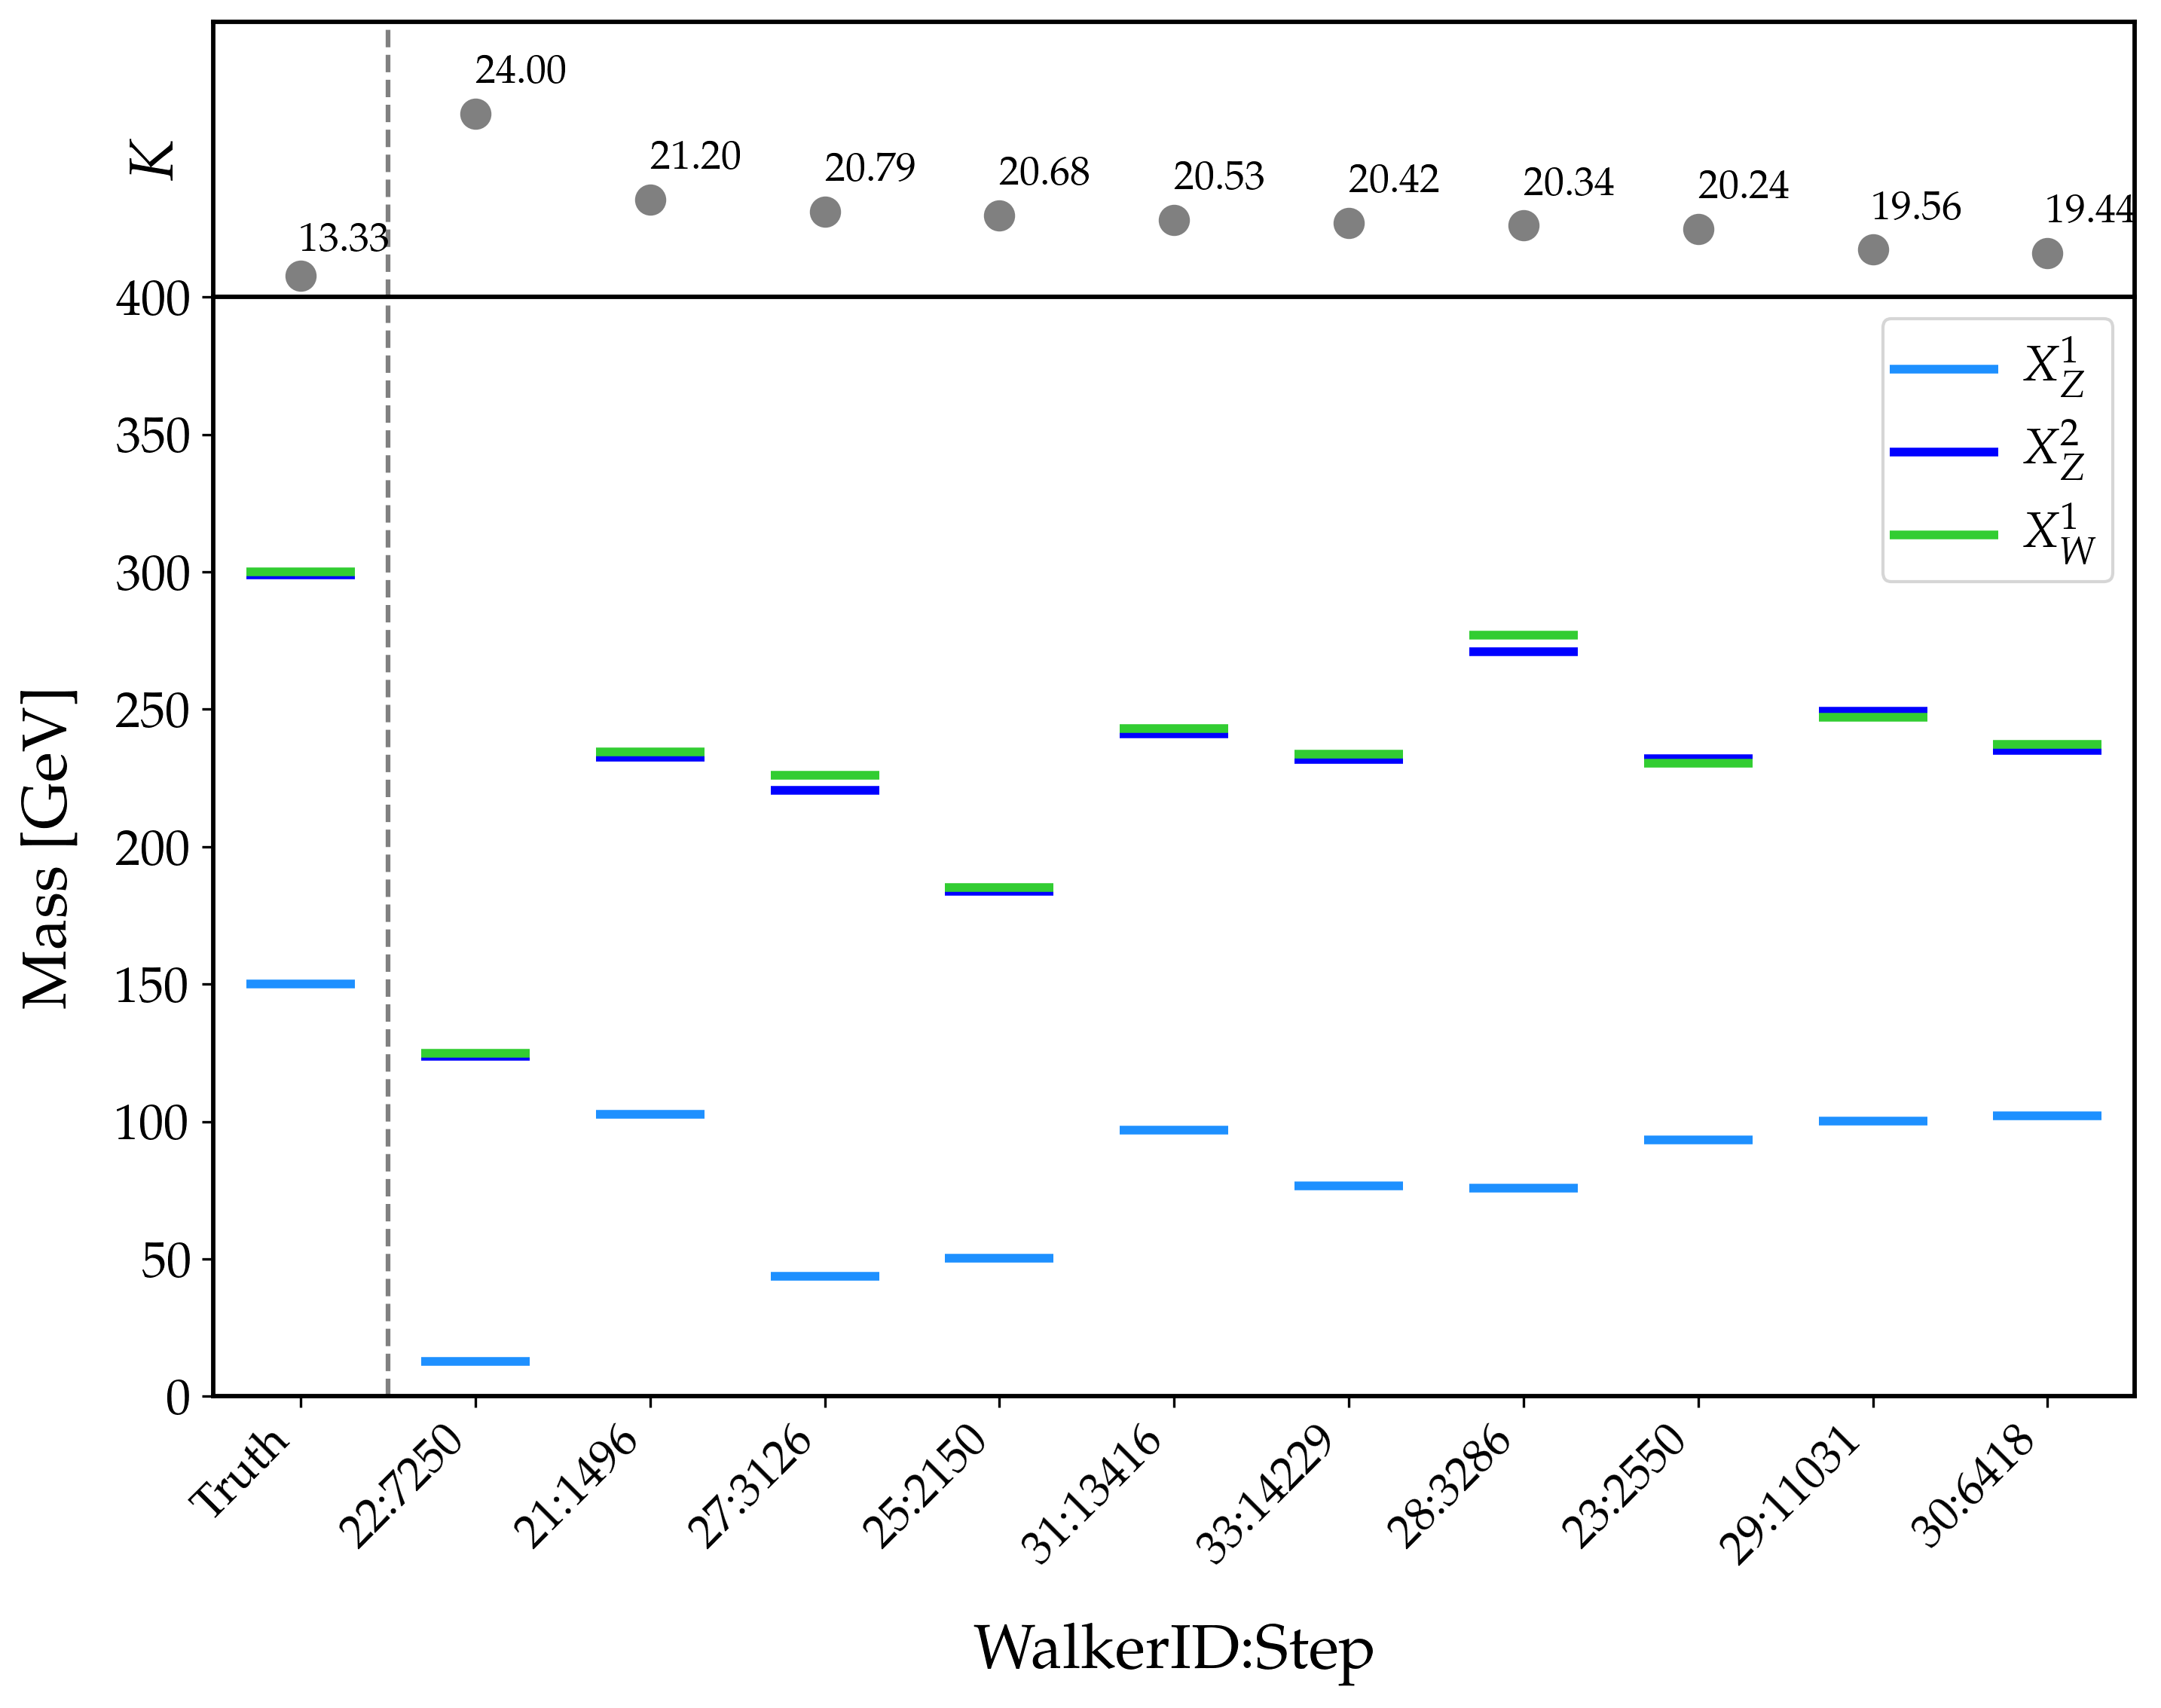

In [11]:
f, axarr = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[1, 4]},figsize=(10,8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0)

nsteps = 10

axarr[0].scatter(df['walkerid'],df['K'],s=80,c='gray')
axarr[0].set_ylabel(r'$K$', fontsize=20)
axarr[0].set_ylim(18.0,27.0)
axarr[0].set_yticks([])

pids = sorted(list(masses.keys()))

for i,row in df.iterrows():
    axarr[0].annotate(rf'{row["K"]:1.2f}',(row['walkerid'],(row["K"]) + 1),fontsize=13)
    if i==0:
        axarr[0].annotate(rf'{row["K"]:1.2f}',(row['walkerid'],19.5),fontsize=13)
        axarr[0].scatter(df['walkerid'][0],18.7,s=80,c='gray')


axarr[0].vlines(x=0.5,ymin=18,ymax=27,linestyle='--',color='gray')

for pid in pids:    
    data = df
    if pid ==1000023:
        sns.scatterplot(x=[0],y=data[pid][0]-1, s=1200, marker='_', legend=False,c=[colorDict[pid]],ax=axarr[1])
        sns.scatterplot(x=data['walkerid'][1:],y=data[pid][1:], s=1200, marker='_',label=r'$%s$' %(particleLabels[pid]), legend=True,c=[colorDict[pid]],ax=axarr[1])
    else:
        sns.scatterplot(x=data['walkerid'],y=data[pid], s=1200, marker='_',label=r'$%s$' %(particleLabels[pid]), legend=True,c=[colorDict[pid]],ax=axarr[1])


axarr[1].set_ylim(0.,400.0)
axarr[1].set_xlabel('WalkerID:Step', fontsize=20, labelpad=15)
axarr[1].set_ylabel('Mass [GeV]', fontsize=20, labelpad=10)
axarr[1].set_xticks(sorted(df['walkerid'].tolist()), labels =sorted(df['walkerid'].tolist()),  fontsize=15, rotation=45, ha='right')
axarr[1].vlines(x=0.5,ymin=0,ymax=400,linestyle='--',color='gray')

leg = axarr[1].legend()
plt.setp(leg.get_texts(), fontsize=16)
plt.ylim(0.,400.0)


plt.show()